In [6]:
from pathlib import Path
import random
import os

SEED = 42
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MODELS_DIR = BASE_DIR / "models"

random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODELS_DIR:", MODELS_DIR)

BASE_DIR: /home/irfat/Projet_Tumeur
DATA_DIR: /home/irfat/Projet_Tumeur/data
OUTPUT_DIR: /home/irfat/Projet_Tumeur/outputs
MODELS_DIR: /home/irfat/Projet_Tumeur/models


In [7]:
import sys
print(sys.version)

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    print("Imports OK")
except ImportError as error:
    print("Erreur d'import:", error)

3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Imports OK


In [9]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
import kagglehub

# Télécharger le dataset
dataset_path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
dataset_path = Path(dataset_path)

print(f"Dataset téléchargé à: {dataset_path}")

# Vérifier les dossiers de classes
yes_folder = dataset_path / "yes"
no_folder = dataset_path / "no"

print(f"\nDossier 'yes' existe: {yes_folder.exists()}")
print(f"Dossier 'no' existe: {no_folder.exists()}")

# Compter les images par classe
if yes_folder.exists():
    yes_images = list(yes_folder.glob("*.jpg")) + list(yes_folder.glob("*.png"))
    print(f"Nombre d'images en 'yes': {len(yes_images)}")

if no_folder.exists():
    no_images = list(no_folder.glob("*.jpg")) + list(no_folder.glob("*.png"))
    print(f"Nombre d'images en 'no': {len(no_images)}")

100%|██████████| 15.1M/15.1M [00:02<00:00, 5.59MB/s]

Extracting files...
Dataset téléchargé à: /home/irfat/.cache/kagglehub/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/versions/1

Dossier 'yes' existe: True
Dossier 'no' existe: True
Nombre d'images en 'yes': 87
Nombre d'images en 'no': 86


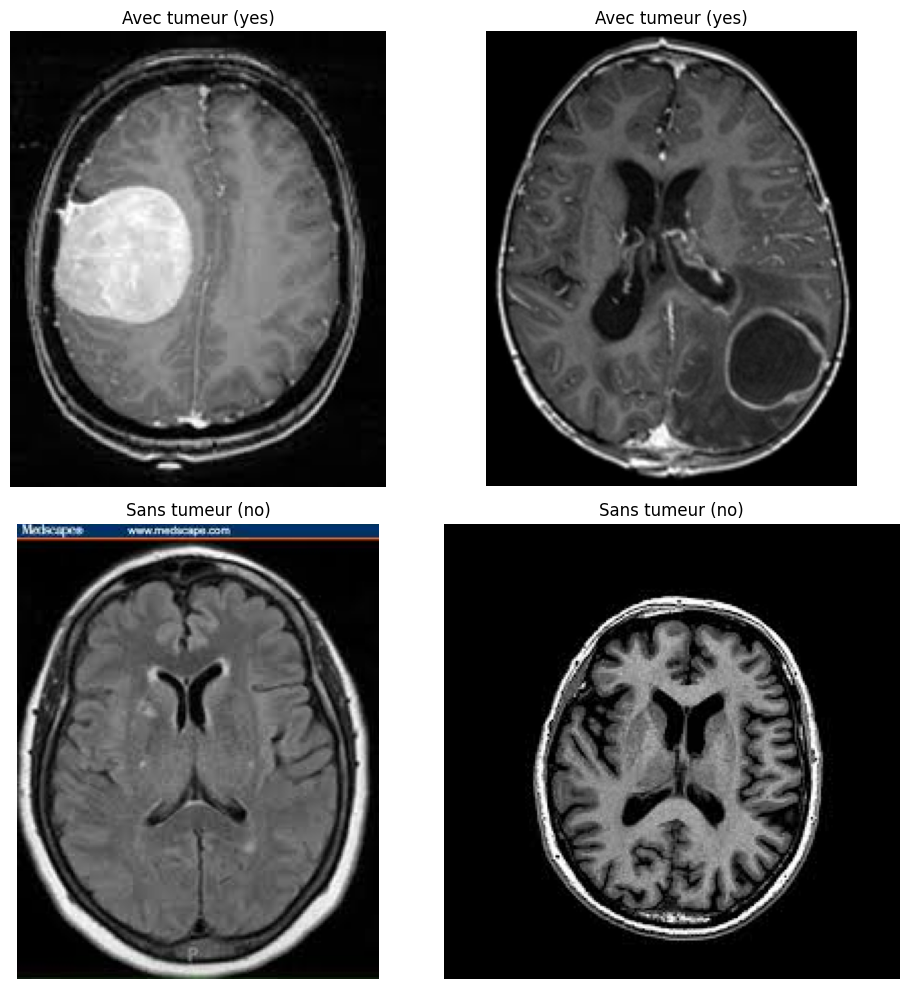

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# Charger quelques images de chaque classe
yes_images_list = list(yes_folder.glob("*.jpg")) + list(yes_folder.glob("*.png"))
no_images_list = list(no_folder.glob("*.jpg")) + list(no_folder.glob("*.png"))

# Afficher 4 images (2 avec tumeur, 2 sans)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Deux images avec tumeur
img1 = Image.open(yes_images_list[0])
axes[0, 0].imshow(img1, cmap='gray')
axes[0, 0].set_title("Avec tumeur (yes)")
axes[0, 0].axis('off')

img2 = Image.open(yes_images_list[1])
axes[0, 1].imshow(img2, cmap='gray')
axes[0, 1].set_title("Avec tumeur (yes)")
axes[0, 1].axis('off')

# Deux images sans tumeur
img3 = Image.open(no_images_list[0])
axes[1, 0].imshow(img3, cmap='gray')
axes[1, 0].set_title("Sans tumeur (no)")
axes[1, 0].axis('off')

img4 = Image.open(no_images_list[1])
axes[1, 1].imshow(img4, cmap='gray')
axes[1, 1].set_title("Sans tumeur (no)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Redimensionner et normaliser les images
IMG_SIZE = 256
X = []  # Images
y = []  # Labels

# Charger les images avec tumeur
for img_path in yes_images_list:
    try:
        img = Image.open(img_path).convert('L')  
        img = img.resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img) / 255.0) 
        y.append(1) 
    except Exception as e:
        print(f"Erreur avec {img_path}: {e}")

# Charger les images sans tumeur 
for img_path in no_images_list:
    try:
        img = Image.open(img_path).convert('L')  
        img = img.resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img) / 255.0)  
        y.append(0) 
    except Exception as e:
        print(f"Erreur avec {img_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Forme de X: {X.shape}")
print(f"Forme de y: {y.shape}")
print(f"Distribution des labels: yes={np.sum(y)}, no={len(y) - np.sum(y)}")

Forme de X: (173, 256, 256)
Forme de y: (173,)
Distribution des labels: yes=87, no=86


In [14]:
# Première séparation : 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Deuxième séparation : split le 80% en 75% train, 25% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f"Taille train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Taille val: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Taille test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribution train: yes={np.sum(y_train)}, no={len(y_train) - np.sum(y_train)}")
print(f"Distribution val: yes={np.sum(y_val)}, no={len(y_val) - np.sum(y_val)}")
print(f"Distribution test: yes={np.sum(y_test)}, no={len(y_test) - np.sum(y_test)}")

Taille train: 103 (59.5%)
Taille val: 35 (20.2%)
Taille test: 35 (20.2%)

Distribution train: yes=52, no=51
Distribution val: yes=17, no=18
Distribution test: yes=18, no=17


In [15]:
from tensorflow import keras
from tensorflow.keras import layers

# Construire un petit CNN simple
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1776070160.074500   11228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776070160.768352   11228 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776070163.046855   11228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1776070164.135787   11228 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776070164.136954   14451 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERRO

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,529 (56.60 MB)

 Trainable params: 14,838,529 (56.60 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Ajouter une dimension de canal aux données (IMG_SIZE, IMG_SIZE) -> (IMG_SIZE, IMG_SIZE, 1)
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Entraîner le modèle
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

print("Entraînement terminé !")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 738ms/step - accuracy: 0.5534 - loss: 1.3633 - val_accuracy: 0.6571 - val_loss: 0.6845
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.7476 - loss: 0.6587 - val_accuracy: 0.6857 - val_loss: 0.6623
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 709ms/step - accuracy: 0.7573 - loss: 0.5339 - val_accuracy: 0.7143 - val_loss: 0.6025
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 684ms/step - accuracy: 0.6990 - loss: 0.6797 - val_accuracy: 0.7143 - val_loss: 0.6024
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 703ms/step - accuracy: 0.8058 - loss: 0.5036 - val_accuracy: 0.7143 - val_loss: 0.6038
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 670ms/step - accuracy: 0.8155 - loss: 0.4256 - val_accuracy: 0.7143 - val_loss: 0.5934
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 726ms/step - accuracy: 0.8058 - loss: 0.3963 - val_accuracy: 0.6857 - val_loss: 0.6332
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 670ms/step - accuracy: 0.8155 - loss: 0.4122 - val_accuracy: 0.7143 - val_loss:

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# Prédictions sur le jeu de test
y_test_pred = model.predict(X_test)
y_test_pred_binary = (y_test_pred > 0.5).astype(int).flatten()

# Calculer les métriques
acc = accuracy_score(y_test, y_test_pred_binary)
prec = precision_score(y_test, y_test_pred_binary)
recall = recall_score(y_test, y_test_pred_binary)
f1 = f1_score(y_test, y_test_pred_binary)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred_binary)
print(f"\nMatrice de confusion:\n{cm}")

# Rapport détaillé
print("\nRapport de classification:")
print(classification_report(y_test, y_test_pred_binary, target_names=['No Tumor', 'Tumor']))

W0000 00:00:1776070418.332975   14478 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Accuracy:  0.8286
Precision: 0.8750
Recall:    0.7778
F1-Score:  0.8235

Matrice de confusion:
[[15  2]
 [ 4 14]]

Rapport de classification:
              precision    recall  f1-score   support

    No Tumor       0.79      0.88      0.83        17
       Tumor       0.88      0.78      0.82        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35



Modèle sauvegardé à: /home/irfat/Projet_Tumeur/models/brain_tumor_model.keras
Résultats sauvegardés à: /home/irfat/Projet_Tumeur/outputs/results.json
Graphe d'entraînement sauvegardé à: /home/irfat/Projet_Tumeur/outputs/training_history.png


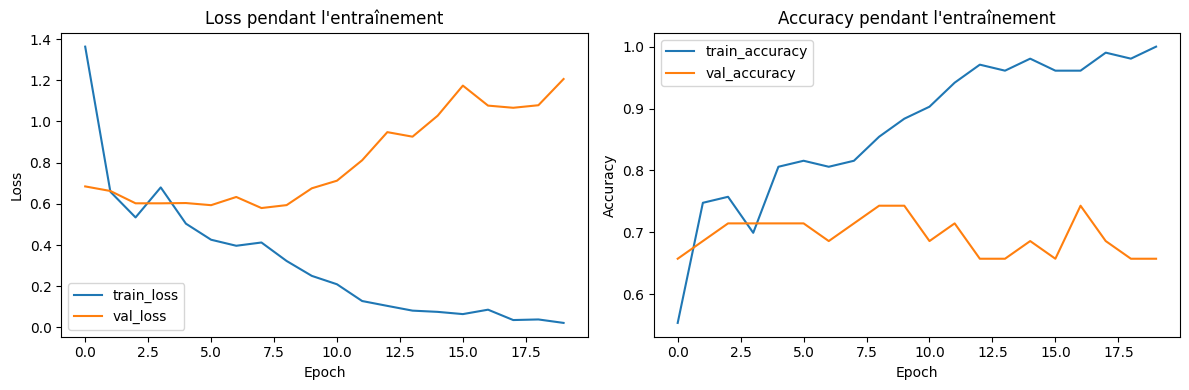

In [18]:
# Créer les dossiers de sortie s'ils n'existent pas
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarder le modèle
model_path = MODELS_DIR / "brain_tumor_model.keras"
model.save(model_path)
print(f"Modèle sauvegardé à: {model_path}")

# Sauvegarder les résultats d'évaluation
results = {
    'accuracy': acc,
    'precision': prec,
    'recall': recall,
    'f1_score': f1,
    'confusion_matrix': cm.tolist()
}

import json
results_path = OUTPUT_DIR / "results.json"
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)
print(f"Résultats sauvegardés à: {results_path}")

# Sauvegarder l'historique d'entraînement en plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss pendant l\'entraînement')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy pendant l\'entraînement')

plt.tight_layout()
loss_plot_path = OUTPUT_DIR / "training_history.png"
plt.savefig(loss_plot_path)
print(f"Graphe d'entraînement sauvegardé à: {loss_plot_path}")
plt.show()